# Static Visualizations – Matplotlib & Seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('plots', exist_ok=True)

# load cleaned data (run notebook 01 first, or upload demand_clean.csv)
try:
    df = pd.read_csv('data/demand_clean.csv', parse_dates=['Date'])
except FileNotFoundError:
    from google.colab import files
    print("Upload demand_clean.csv")
    uploaded = files.upload()
    import io
    df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), parse_dates=['Date'])

df['year']    = df['Date'].dt.year
df['month']   = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter
print(df.shape)

(1048575, 8)


## 1. Total Demand per Warehouse (Bar Chart)

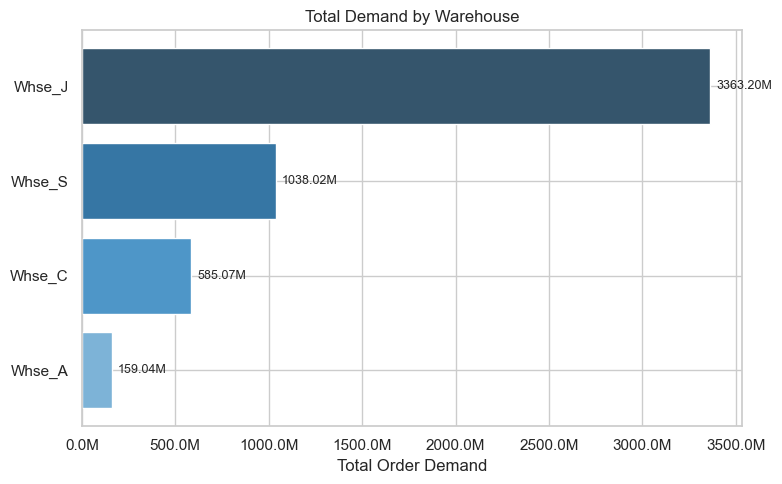

In [3]:
by_wh = df.groupby('Warehouse')['Order_Demand'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(by_wh.index, by_wh.values, color=sns.color_palette('Blues_d', len(by_wh)))
ax.set_xlabel('Total Order Demand')
ax.set_title('Total Demand by Warehouse')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar in bars:
    ax.text(bar.get_width() + by_wh.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width()/1e6:.2f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/01_demand_by_warehouse.png', dpi=150)
plt.show()

## 2. Demand by Product Category

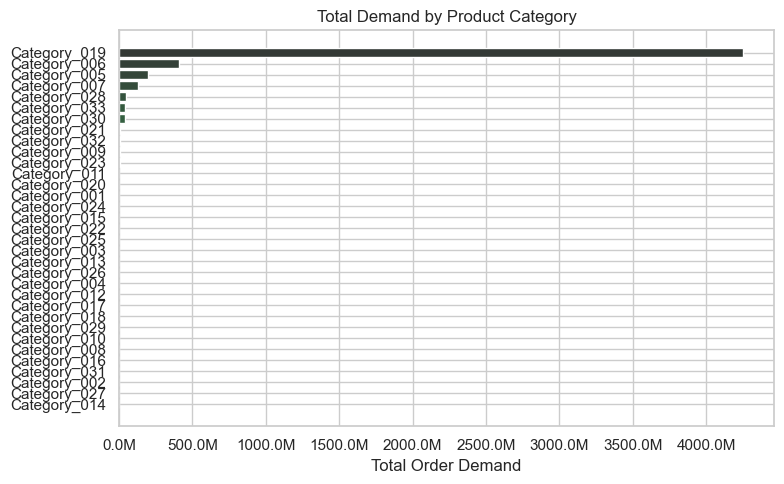

In [4]:
by_cat = df.groupby('Product_Category')['Order_Demand'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_cat.index, by_cat.values, color=sns.color_palette('Greens_d', len(by_cat)))
ax.set_xlabel('Total Order Demand')
ax.set_title('Total Demand by Product Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('plots/02_demand_by_category.png', dpi=150)
plt.show()

## 3. Monthly Demand Trend

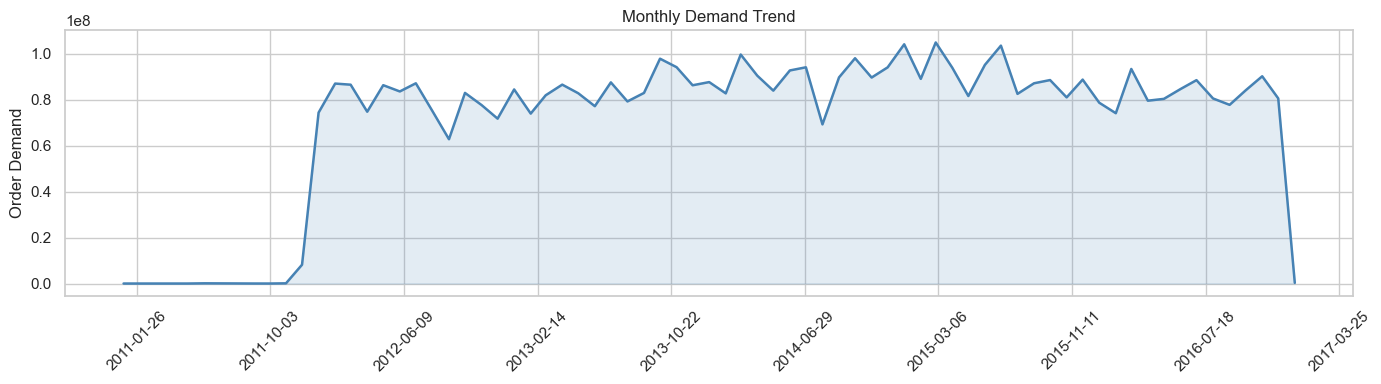

In [5]:
monthly = (df.dropna(subset=['Date'])
             .groupby(df['Date'].dt.to_period('M'))['Order_Demand']
             .sum()
             .reset_index())
monthly.columns = ['period', 'demand']
monthly['period'] = monthly['period'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['period'], monthly['demand'], linewidth=1.8, color='steelblue')
ax.fill_between(monthly['period'], monthly['demand'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Demand Trend')
ax.set_ylabel('Order Demand')
ax.xaxis.set_major_locator(plt.MaxNLocator(12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/03_monthly_trend.png', dpi=150)
plt.show()

## 4. Yearly Demand – Grouped Bar

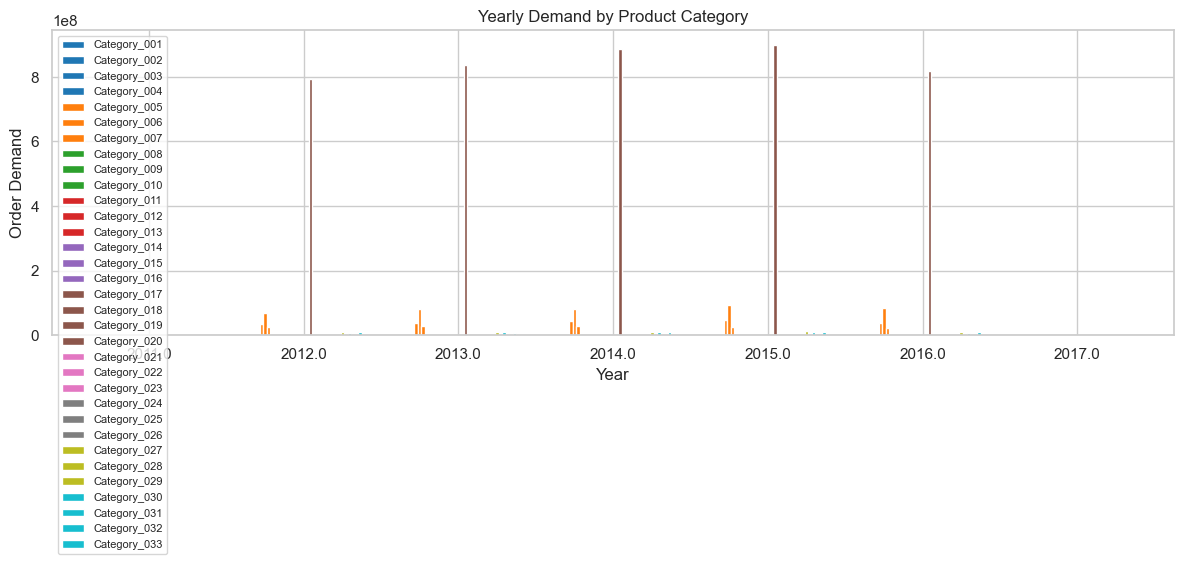

In [6]:
yearly_cat = df.groupby(['year', 'Product_Category'])['Order_Demand'].sum().unstack(fill_value=0)

yearly_cat.plot(kind='bar', figsize=(12, 5), colormap='tab10', width=0.75)
plt.title('Yearly Demand by Product Category')
plt.ylabel('Order Demand')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('plots/04_yearly_by_category.png', dpi=150)
plt.show()

## 5. Demand Distribution – Box Plot

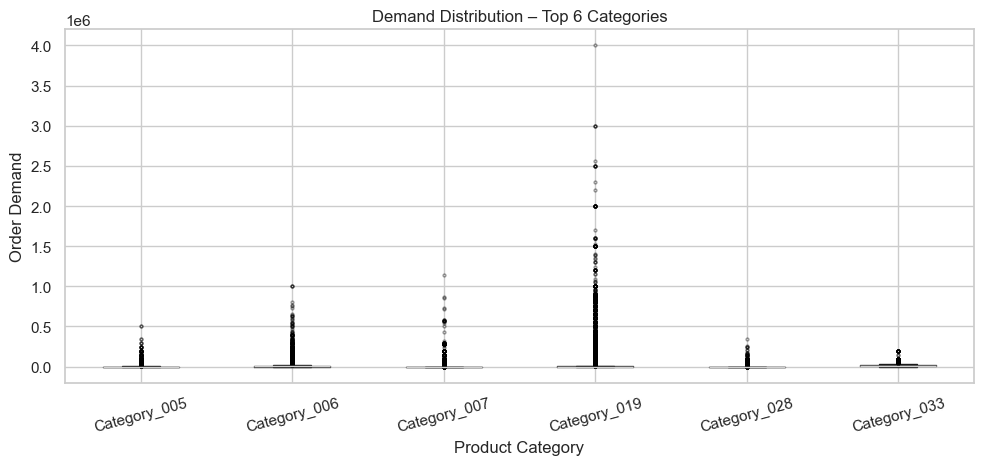

In [7]:
top_cats = df.groupby('Product_Category')['Order_Demand'].sum().nlargest(6).index
df_top = df[df['Product_Category'].isin(top_cats)]

fig, ax = plt.subplots(figsize=(10, 5))
df_top.boxplot(column='Order_Demand', by='Product_Category', ax=ax,
               flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_title('Demand Distribution – Top 6 Categories')
ax.set_xlabel('Product Category')
ax.set_ylabel('Order Demand')
plt.suptitle('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plots/05_boxplot_distribution.png', dpi=150)
plt.show()

## 6. Top 15 Products – Pareto

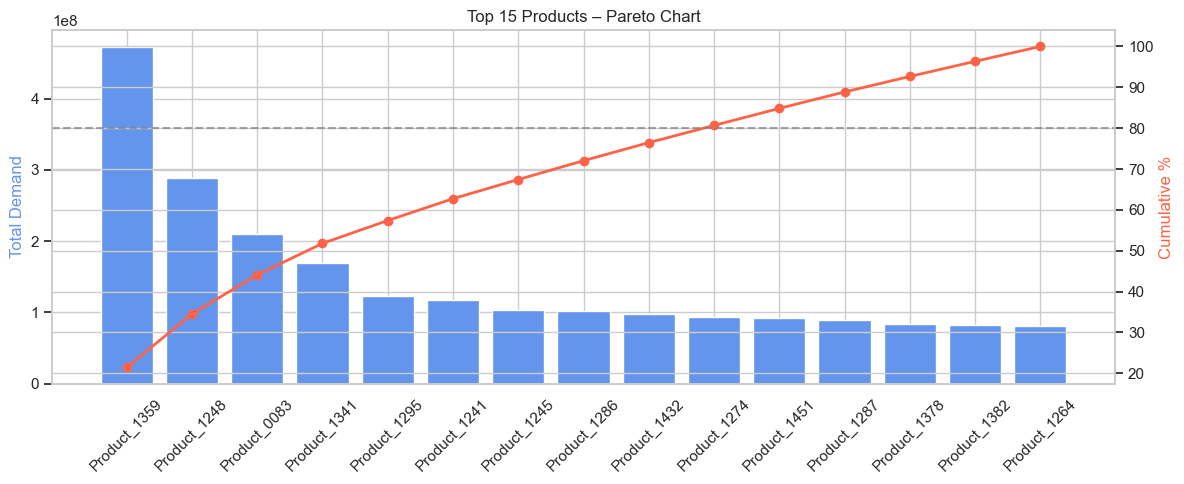

In [8]:
top15 = df.groupby('Product_Code')['Order_Demand'].sum().nlargest(15).reset_index()
top15['cumulative_pct'] = top15['Order_Demand'].cumsum() / top15['Order_Demand'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(top15['Product_Code'], top15['Order_Demand'], color='cornflowerblue')
ax1.set_ylabel('Total Demand', color='cornflowerblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(top15['Product_Code'], top15['cumulative_pct'], 'o-', color='tomato', linewidth=2)
ax2.set_ylabel('Cumulative %', color='tomato')
ax2.axhline(80, linestyle='--', color='gray', alpha=0.7)

ax1.set_title('Top 15 Products – Pareto Chart')
plt.tight_layout()
plt.savefig('plots/06_pareto_top_products.png', dpi=150)
plt.show()

## 7. Heatmap – Warehouse × Month

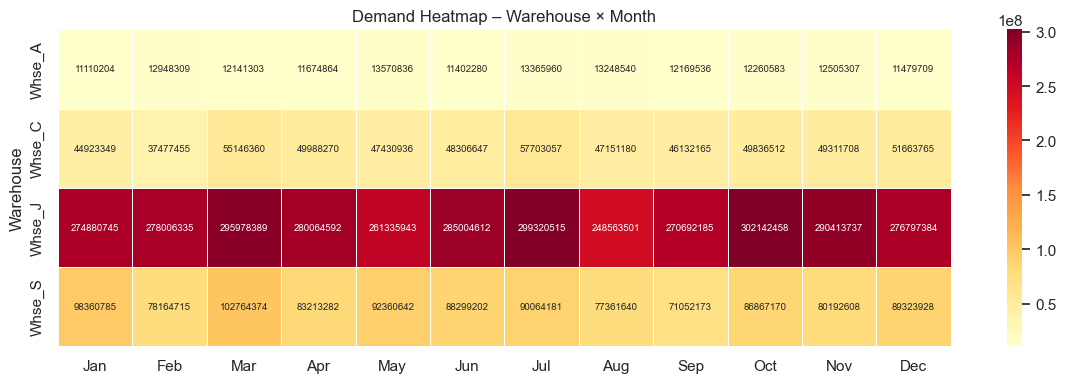

In [9]:
hm = df.groupby(['Warehouse', 'month'])['Order_Demand'].sum().unstack(fill_value=0)
hm.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(hm, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Demand Heatmap – Warehouse × Month')
plt.tight_layout()
plt.savefig('plots/07_heatmap_warehouse_month.png', dpi=150)
plt.show()

## 8. Quarterly Demand Trend

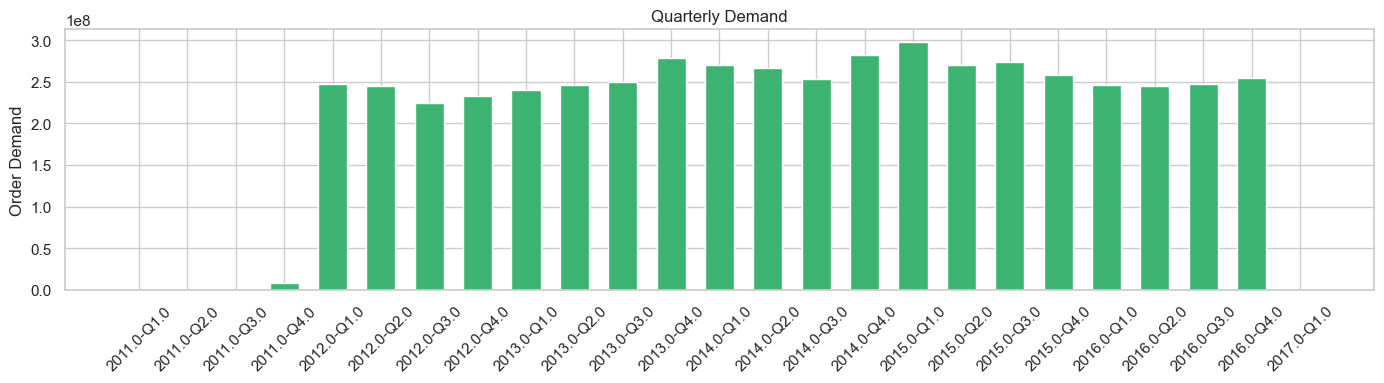

In [10]:
quarterly = df.groupby(['year', 'quarter'])['Order_Demand'].sum().reset_index()
quarterly['label'] = quarterly['year'].astype(str) + '-Q' + quarterly['quarter'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(quarterly['label'], quarterly['Order_Demand'], color='mediumseagreen', width=0.6)
ax.set_title('Quarterly Demand')
ax.set_ylabel('Order Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/08_quarterly_demand.png', dpi=150)
plt.show()

In [11]:
print("All plots saved to /plots/")

All plots saved to /plots/
